In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('./data/fraudTest.csv', index_col=0)

In [4]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  555719 non-null  object 
 1   cc_num                 555719 non-null  int64  
 2   merchant               555719 non-null  object 
 3   category               555719 non-null  object 
 4   amt                    555719 non-null  float64
 5   first                  555719 non-null  object 
 6   last                   555719 non-null  object 
 7   gender                 555719 non-null  object 
 8   street                 555719 non-null  object 
 9   city                   555719 non-null  object 
 10  state                  555719 non-null  object 
 11  zip                    555719 non-null  int64  
 12  lat                    555719 non-null  float64
 13  long                   555719 non-null  float64
 14  city_pop               555719 non-null  i

In [6]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

# Data Dictionary

* `trans_date_trans_time` - 거래 타임스탬프 (날짜 및 시간)
* `cc_num` - 신용카드 번호
* `merchant` - 가맹점 이름
* `category` - 거래 카테고리
* `amt` - 거래 금액
* `first` - 카드 소지자 이름 (이름)
* `last` - 카드 소지자 이름 (성)
* `gender` - 카드 소지자의 성별
* `street` - 거래 주소
* `city` - 거래 도시
* `state` - 거래 주 (state)
* `zip` - 거래 우편번호
* `lat` - 거래 위도
* `long` - 거래 경도
* `city_pop` - 도시 인구수
* `job` - 카드 소지자의 직업
* `dob` - 카드 소지자의 생년월일
* `trans_num` - 거래 고유 번호
* `unix_time` - 유닉스 시간
* `merch_lat` - 가맹점 위도
* `merch_long` - 가맹점 경도
* `is_fraud` - 사기 여부 (1: 사기, 0: 정상)

In [7]:
df.nunique()

trans_date_trans_time    544760
cc_num                      924
merchant                    693
category                     14
amt                       37256
first                       341
last                        471
gender                        2
street                      924
city                        849
state                        50
zip                         912
lat                         910
long                        910
city_pop                    835
job                         478
dob                         910
trans_num                555719
unix_time                544760
merch_lat                546490
merch_long               551770
is_fraud                      2
dtype: int64

In [8]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [9]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [40]:
# trans_date_trans_time 에서 시간, 분, 요일, 년도-월 추출 

df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_minute'] = df['trans_date_trans_time'].dt.minute
df['trans_day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['trans_year_month'] = df['trans_date_trans_time'].dt.to_period('M')

In [41]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_minute,trans_day_of_week,trans_year_month,age
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,14,6,2020-06,52
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,14,6,2020-06,30
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,14,6,2020-06,49
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,15,6,2020-06,32
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,15,6,2020-06,64


In [38]:
# dob에서 나이 추출, age는 거래당시의 나이

df['dob'] = pd.to_datetime(df['dob'])

from dateutil.relativedelta import relativedelta

def calculate_age(born, trans_date):
    return relativedelta(trans_date, born).years

df['age'] = df.apply(lambda x: calculate_age(x['dob'], x['trans_date_trans_time']), axis=1)

In [39]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_minute,trans_day_of_week,trans_year_month,age
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,14,6,2020-06,52
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,14,6,2020-06,30
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,14,6,2020-06,49
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,15,6,2020-06,32
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,15,6,2020-06,64


In [42]:
# 전처리 이후 필요없는 변수(trans_date_trans_time, dob) 제거

df.drop(['trans_date_trans_time', 'dob'], axis=1, inplace=True)

In [49]:
# merchant, category 통합

df['merchant_category'] = df['merchant'].fillna('') + ':' + df['category'].fillna('')

In [50]:
df.head()

,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_minute,trans_day_of_week,trans_year_month,age,merchant_category
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,14,6,2020-06,52,fraud_Kirlin and Sons:personal_care
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,14,6,2020-06,30,fraud_Sporer-Keebler:personal_care
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,14,6,2020-06,49,"fraud_Swaniawski, Nitzsche and Welch:health_fi..."
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,15,6,2020-06,32,fraud_Haley Group:misc_pos
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,15,6,2020-06,64,fraud_Johnston-Casper:travel


In [57]:
# 이름 및 거래 고유 번호 제거

df_non_name = df.drop(['first', 'last', 'trans_num'], axis=1) 

In [58]:
df_non_name.head()

,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_minute,trans_day_of_week,trans_year_month,age,merchant_category
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1371816865,33.986391,-81.200714,0,12,14,6,2020-06,52,fraud_Kirlin and Sons:personal_care
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1371816873,39.450498,-109.960431,0,12,14,6,2020-06,30,fraud_Sporer-Keebler:personal_care
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1371816893,40.495810,-74.196111,0,12,14,6,2020-06,49,"fraud_Swaniawski, Nitzsche and Welch:health_fi..."
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1371816915,28.812398,-80.883061,0,12,15,6,2020-06,32,fraud_Haley Group:misc_pos
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1371816917,44.959148,-85.884734,0,12,15,6,2020-06,64,fraud_Johnston-Casper:travel


In [59]:
# merchant, category, gender, street, city, state, job, trans_year_month, merchant_category 칼럼 라벨인코딩

from sklearn.preprocessing import LabelEncoder

label_cols = ['merchant', 'category', 'gender', 'street', 'city', 'state', 'job', 'trans_year_month', 'merchant_category']

for col in label_cols:
    le = LabelEncoder()
    df_non_name[col] = le.fit_transform(df_non_name[col])

In [60]:
df_non_name.head()

,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_minute,trans_day_of_week,trans_year_month,age,merchant_category
0,2291163933867244,319,10,2.86,1,341,157,39,29209,33.9659,-80.9355,333497,275,1371816865,33.986391,-81.200714,0,12,14,6,0,52,324
1,3573030041201292,591,10,29.84,0,354,16,43,84002,40.3207,-110.4360,302,392,1371816873,39.450498,-109.960431,0,12,14,6,0,30,598
2,3598215285024754,611,5,41.28,0,865,61,33,11710,40.6729,-73.5365,34496,259,1371816893,40.495810,-74.196111,0,12,14,6,0,49,618
3,3591919803438423,222,9,60.05,1,320,764,8,32780,28.5697,-80.8191,54767,407,1371816915,28.812398,-80.883061,0,12,15,6,0,32,226
4,3526826139003047,292,13,3.19,1,548,247,21,49632,44.2529,-85.0170,1126,196,1371816917,44.959148,-85.884734,0,12,15,6,0,64,296


* 수치형 변수 : amt, lat, long, city_pop, unix_time, merch_lat, merch_long, age
* 범주형 변수 : cc_num, merchant, category, gender, street, city, state, zip, job, trans_hour, trans_minute, trans_day_of_week, trans_year_month, merchant_category
* 타겟 : is_fraud

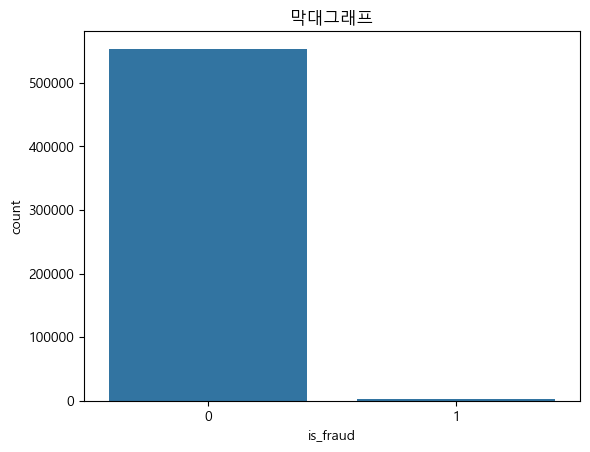

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

sns.countplot(x='is_fraud', data=df_non_name)
plt.title("막대그래프")
plt.show()

1. 모든 변수별 타겟 변수와의 관계

타겟과 변수 간 통계 검정 요약 결과:
           Variable A Variable B Test Type        p-value
0                 amt   is_fraud    T-test   0.000000e+00
17         trans_hour   is_fraud      Chi2   0.000000e+00
16                job   is_fraud      Chi2   0.000000e+00
15                zip   is_fraud      Chi2   0.000000e+00
13               city   is_fraud      Chi2   0.000000e+00
12             street   is_fraud      Chi2   0.000000e+00
8              cc_num   is_fraud      Chi2   0.000000e+00
10           category   is_fraud      Chi2   0.000000e+00
21  merchant_category   is_fraud      Chi2  2.587206e-212
9            merchant   is_fraud      Chi2  1.802227e-205
14              state   is_fraud      Chi2   6.739749e-66
20   trans_year_month   is_fraud      Chi2   5.057005e-48
19  trans_day_of_week   is_fraud      Chi2   2.114935e-25
4           unix_time   is_fraud    T-test   2.022592e-22
7                 age   is_fraud    T-test   4.572667e-08
1                 lat   is_fraud    T-test   1.238

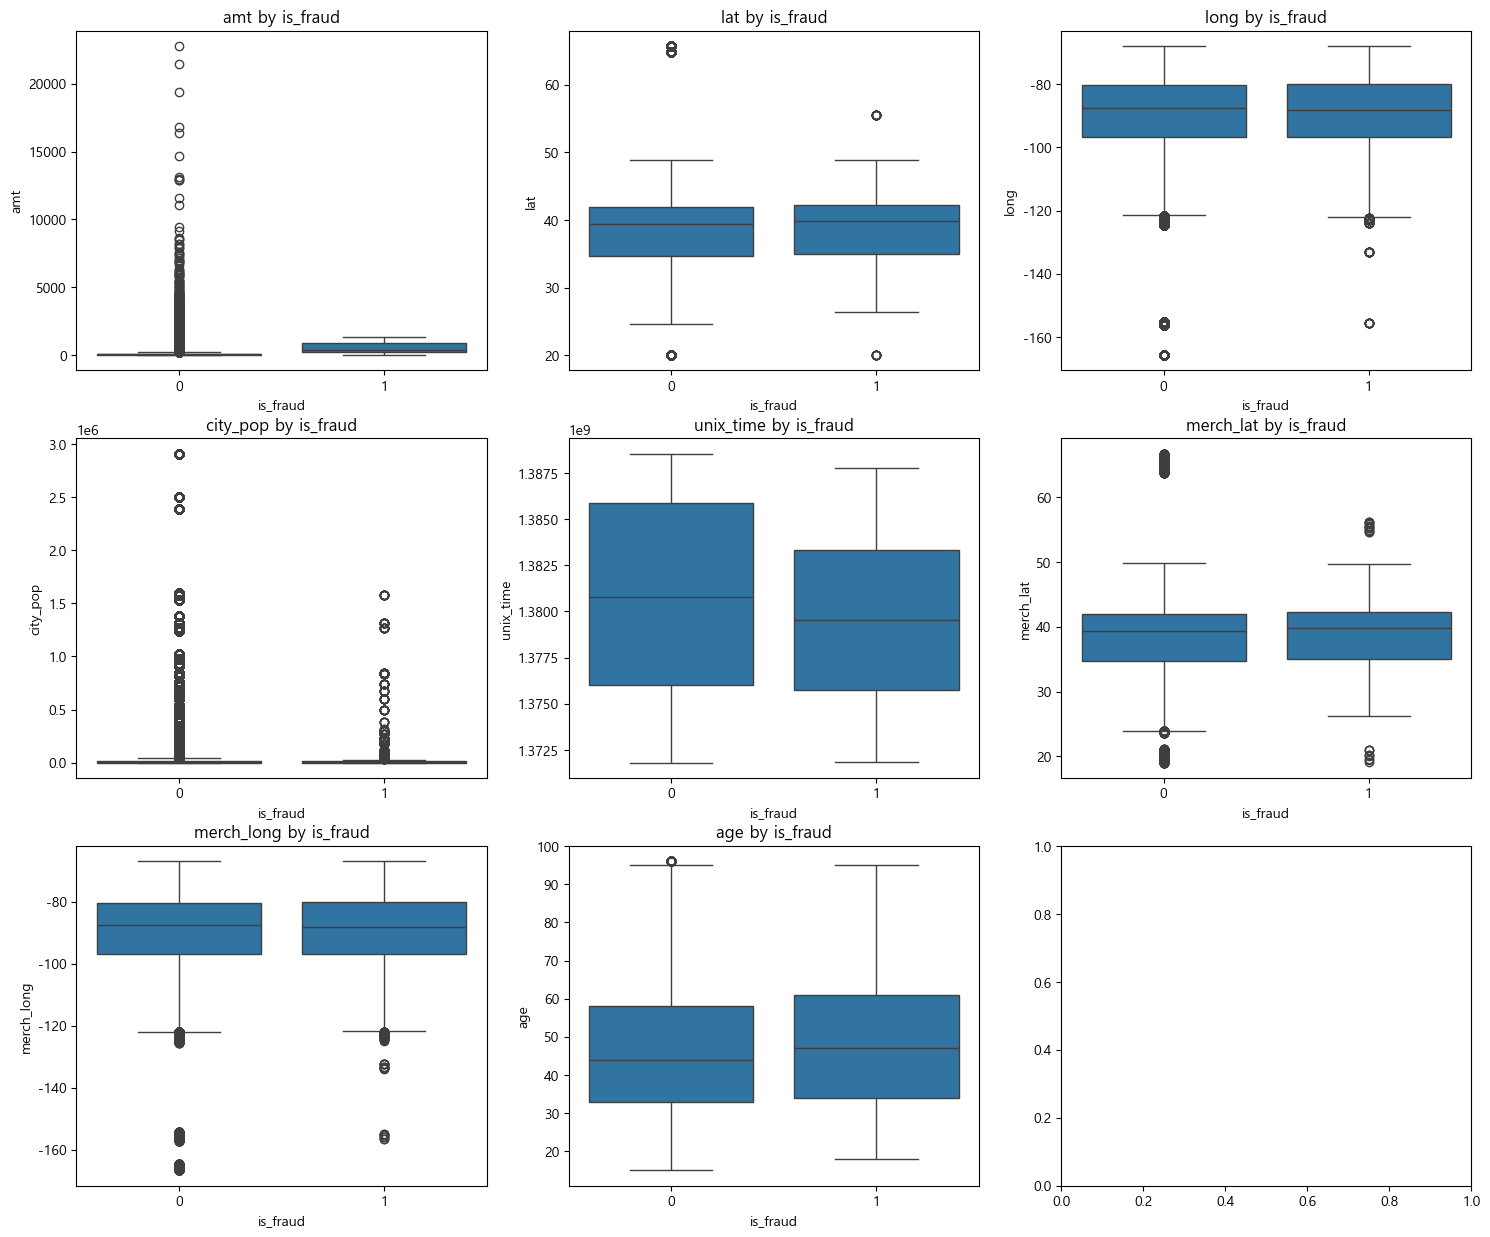

In [73]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
import warnings
warnings.filterwarnings("ignore")

numeric_cols = ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'age']
categorical_cols = ['cc_num', 'merchant', 'category', 'gender', 'street', 'city', 'state', 'zip',
                    'job', 'trans_hour', 'trans_minute', 'trans_day_of_week', 'trans_year_month',
                    'merchant_category']
target_col = 'is_fraud'

eda_results = []

# 수치형 변수, is_fraud (boxplot + T-test)
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for i, num_col in enumerate(numeric_cols):
    if num_col in df_non_name.columns and target_col in df_non_name.columns:
        # Boxplot 그리기
        sns.boxplot(x=target_col, y=num_col, data=df_non_name, ax=axes[i])
        axes[i].set_title(f'{num_col} by {target_col}')
        axes[i].set_xlabel(target_col)
        axes[i].set_ylabel(num_col)

        # T-test 수행
        groups = [df_non_name[df_non_name[target_col] == val][num_col] for val in df_non_name[target_col].unique()]
        if len(groups) == 2:
            stat, p = ttest_ind(groups[0], groups[1])
            eda_results.append((num_col, target_col, "T-test", p))

# 범주형 변수, is_fraud (교차표 + 카이제곱검정)
for cat_col in categorical_cols:
    if cat_col in df_non_name.columns and target_col in df_non_name.columns:
        table = pd.crosstab(df_non_name[cat_col], df_non_name[target_col])
        try:
            chi2, p, dof, _ = chi2_contingency(table)
            eda_results.append((cat_col, target_col, "Chi2", p))
        except:
            pass

# 결과 정리 및 출력
eda_summary = pd.DataFrame(eda_results, columns=['Variable A', 'Variable B', 'Test Type', 'p-value'])
eda_summary = eda_summary.sort_values(by='p-value')
print("타겟과 변수 간 통계 검정 요약 결과:")
print(eda_summary)

변수 중요도

Feature Importances:
amt                  0.317058
category             0.104727
trans_hour           0.092450
unix_time            0.046731
age                  0.046363
merch_long           0.037321
merch_lat            0.036634
merchant_category    0.028569
merchant             0.027096
city_pop             0.026465
cc_num               0.024427
job                  0.023541
trans_minute         0.023524
city                 0.023342
street               0.023090
zip                  0.022063
lat                  0.021075
long                 0.019350
trans_day_of_week    0.017276
trans_year_month     0.016280
state                0.014534
gender               0.008084
dtype: float64


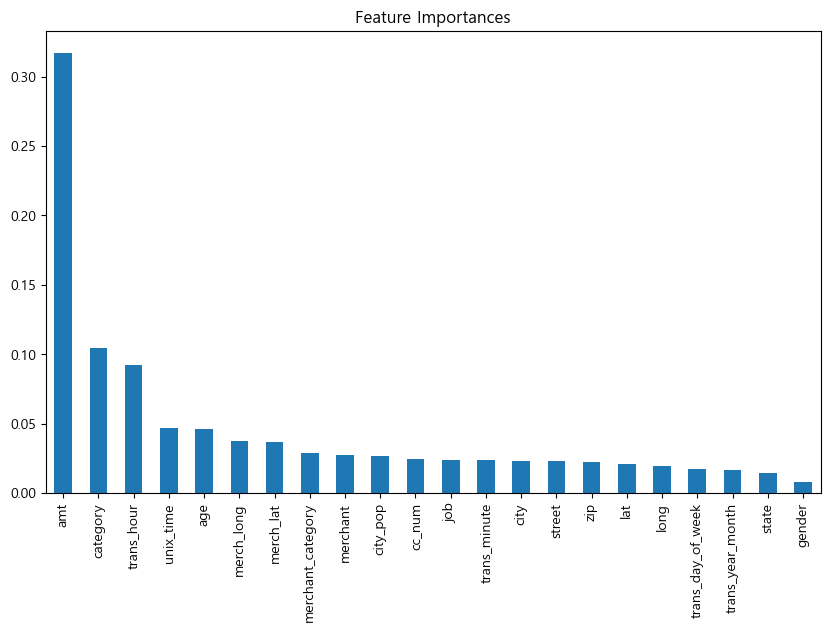

In [70]:
from sklearn.ensemble import RandomForestClassifier

x = df_non_name[numeric_cols + categorical_cols]
y = df_non_name[target_col]

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(x, y)

importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=x.columns)
feat_importances = feat_importances.sort_values(ascending=False)

print("Feature Importances:")
print(feat_importances)

plt.figure(figsize=(10,6))
feat_importances.plot(kind='bar')
plt.title('Feature Importances')
plt.show()

2. 독립변수간 관계

* 수치형 변수, 수치형 변수

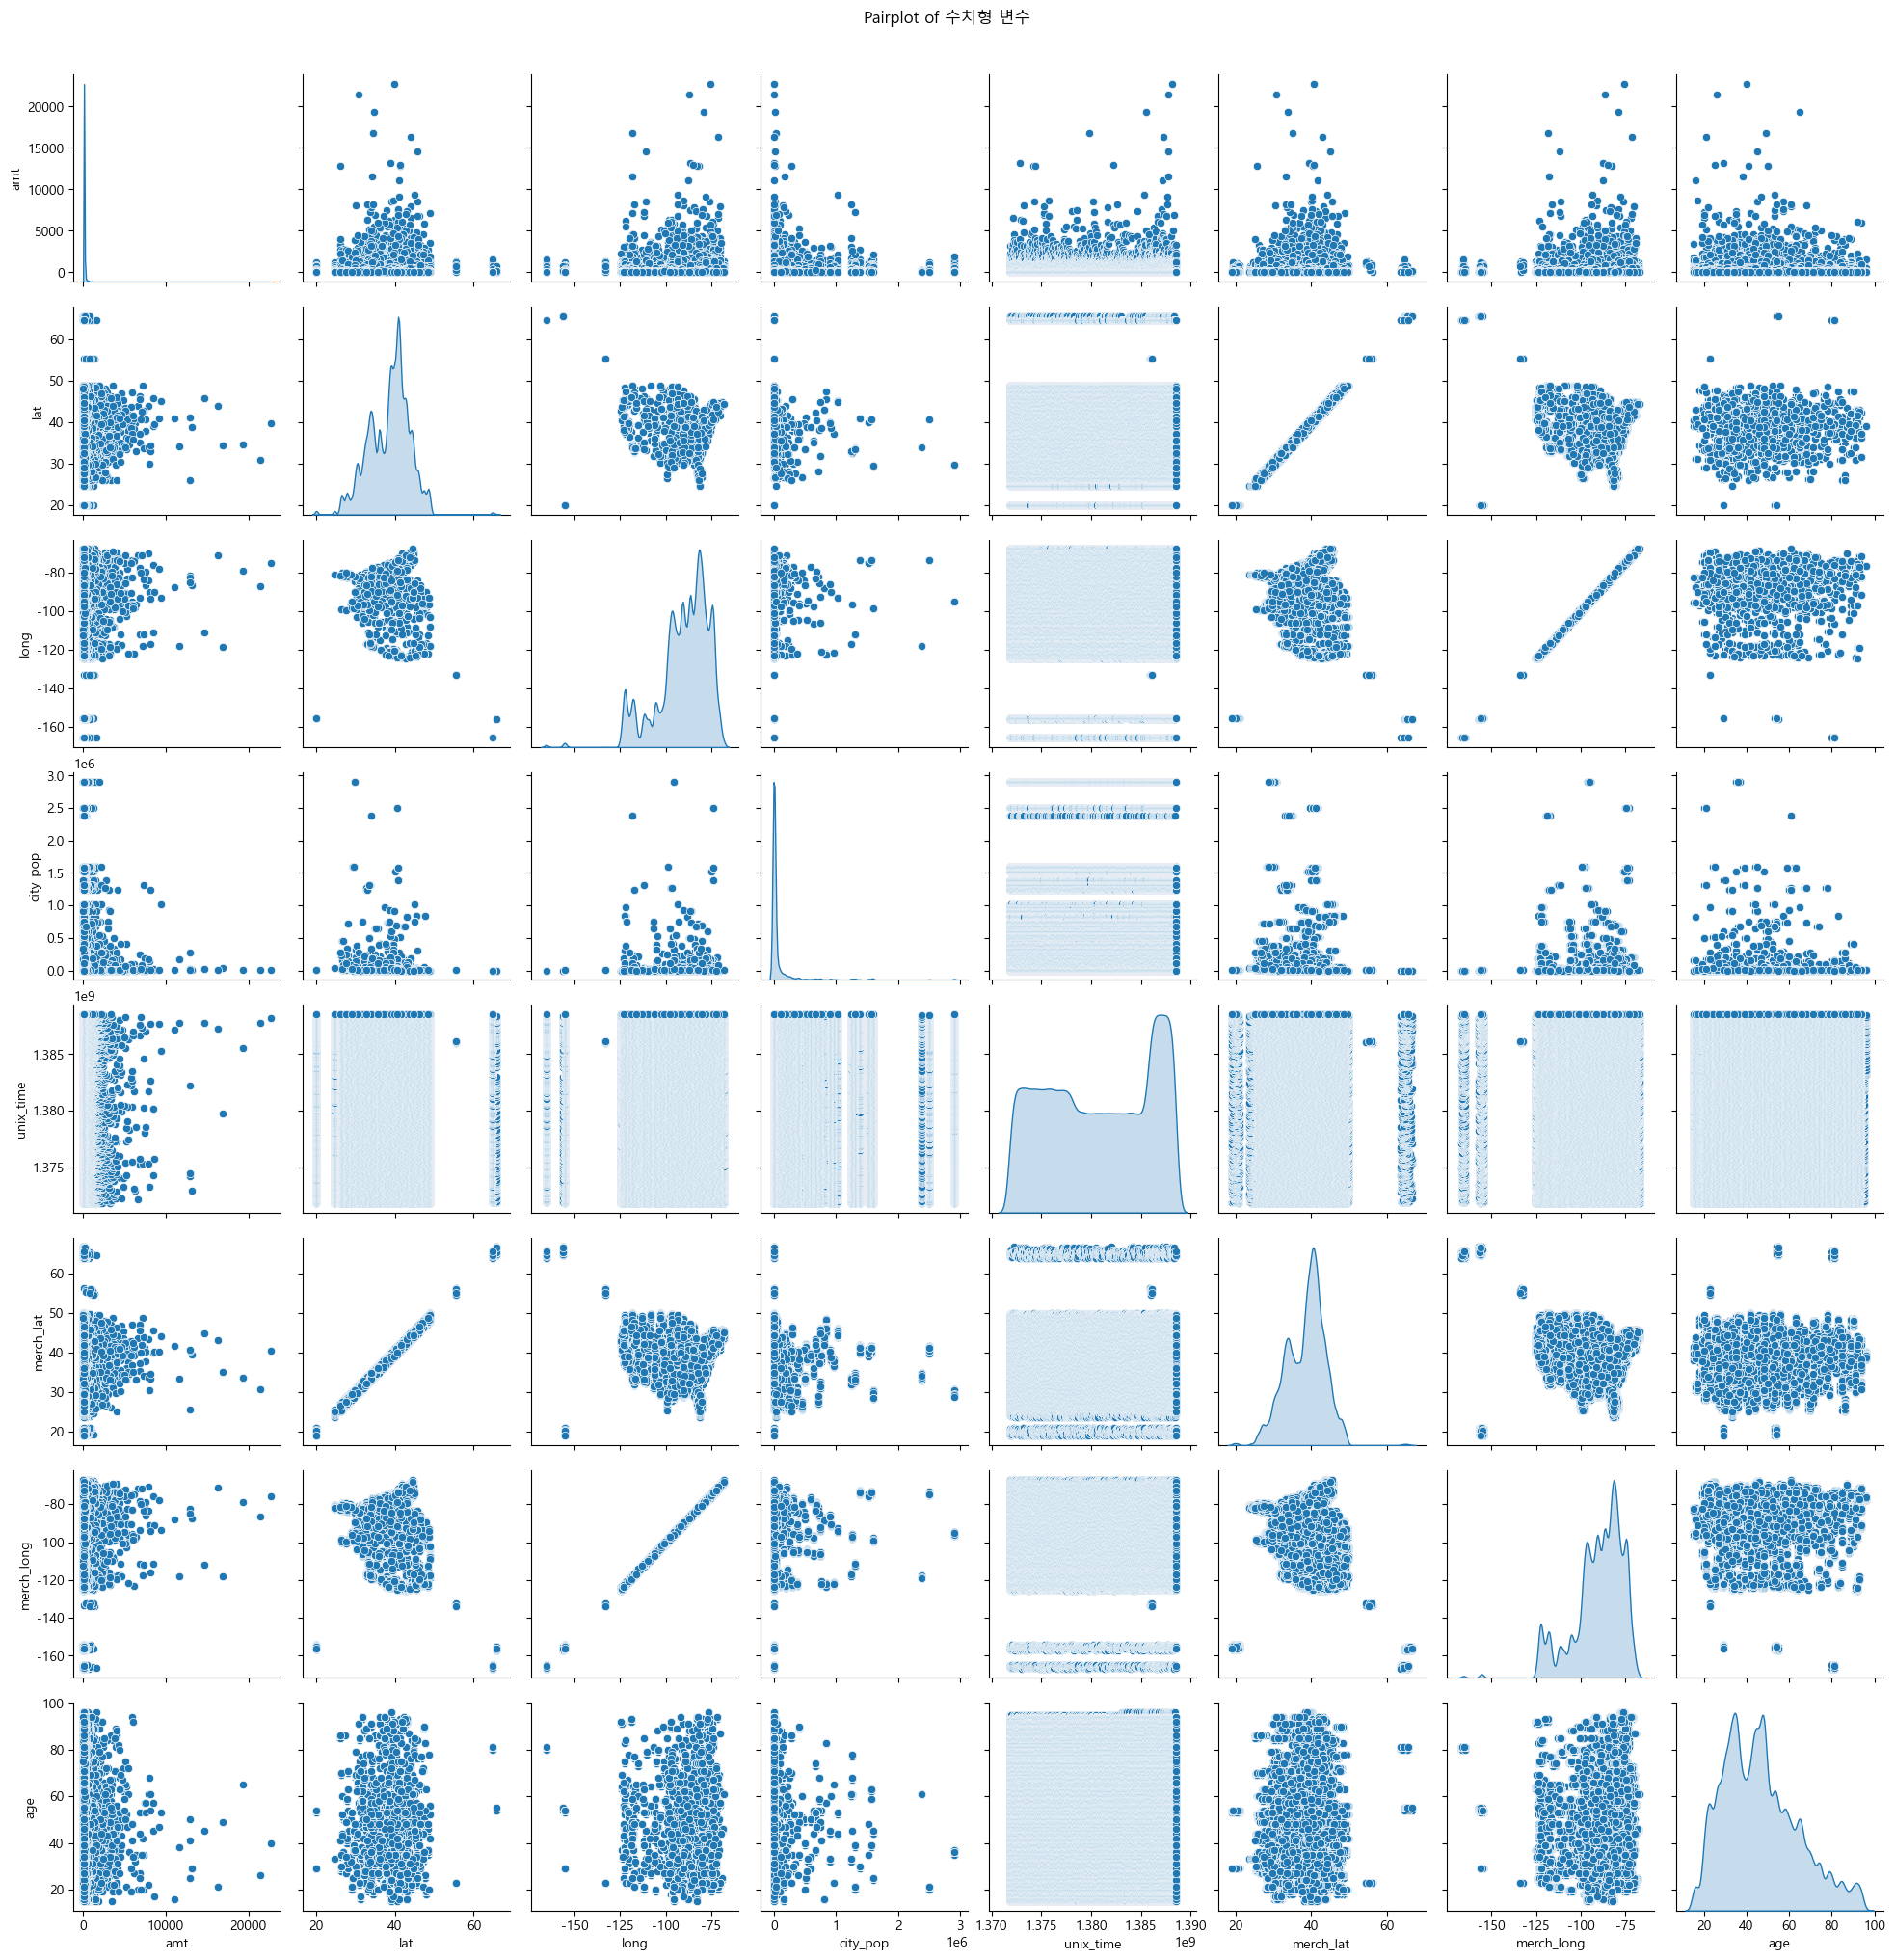

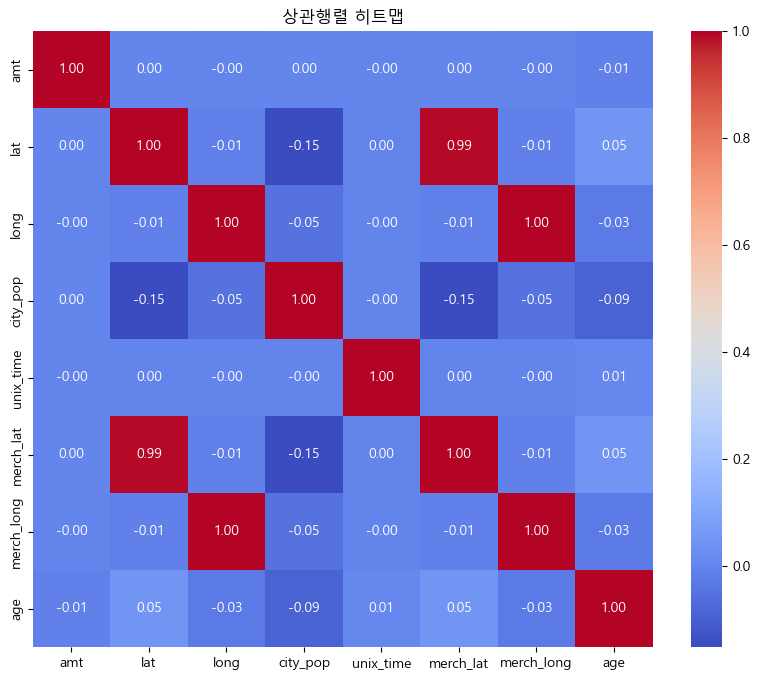

In [74]:
# 수치형 변수

sns.pairplot(df_non_name[numeric_cols], diag_kind='kde')
plt.suptitle('Pairplot of 수치형 변수', y=1.02)
plt.show()

# 수치형 변수 상관행렬 히트맵

corr = df_non_name[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('상관행렬 히트맵')
plt.show()